# Problem 2.15: 2D Image Filtering with Averaging Filters

**Textbook:** Applied Digital Signal Processing (Manolakis & Ingle) - Chapter 2

### Problem Statement:
In this problem use the Lena image shown in Figure 2.23 which is available in the book toolbox.
* **(a)** Load the Lena image in MATLAB/Python and display using `imshow`.
* **(b)** Consider the $3 \times 3$ impulse response $h[m, n]$ given in (2.75). Filter the Lena image using (2.78) and display the resulting image and verify that it looks similar to the corresponding one in Figure 2.23. Assume zero boundary conditions.
* **(c)** Repeat part (b) using the impulse response:
  $$
  h[m, n] = \begin{cases} \frac{1}{25}, & -2 \le m, n \le 2 \\ 0, & \text{otherwise} \end{cases}
  $$
  and comment on the result.

In [2]:
%matplotlib inline
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.signal import convolve2d


## (a) Load and Display Original Lena Image
Load the grayscale Lena image ($512 \times 512$) and display its dimensions and pixel values.

Image size: 512 x 512 pixels
Min intensity: 10.0, Max intensity: 250.0


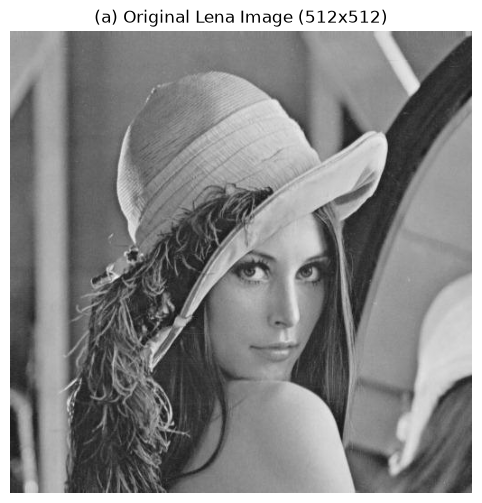

In [4]:
# Load Lena image
image_path = Path('lena.jpg')
if not image_path.exists():
    import urllib.request
    url = 'https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/lena.jpg'
    urllib.request.urlretrieve(url, image_path)

img = Image.open(image_path).convert('L')
x = np.array(img, dtype=np.float64)

print(f'Image size: {x.shape[0]} x {x.shape[1]} pixels')
print(f'Min intensity: {x.min()}, Max intensity: {x.max()}')

plt.figure(figsize=(6, 6))
plt.imshow(x, cmap='gray', vmin=0, vmax=255)
plt.title('(a) Original Lena Image (512x512)')
plt.axis('off')
plt.show()


## (b) 2D Filtering with $3 \times 3$ Averaging Filter (Eq. 2.75)
Equation (2.75) defines the $3 \times 3$ impulse response:
$$
h_1[m, n] = \begin{cases} \frac{1}{9}, & -1 \le m, n \le 1 \\ 0, & \text{otherwise} \end{cases}
$$
Filtering is computed via 2D convolution (Eq. 2.78) with zero boundary conditions:
$$
y_1[m, n] = \sum_{k=-1}^{1} \sum_{l=-1}^{1} h_1[k, l] x[m - k, n - l]
$$

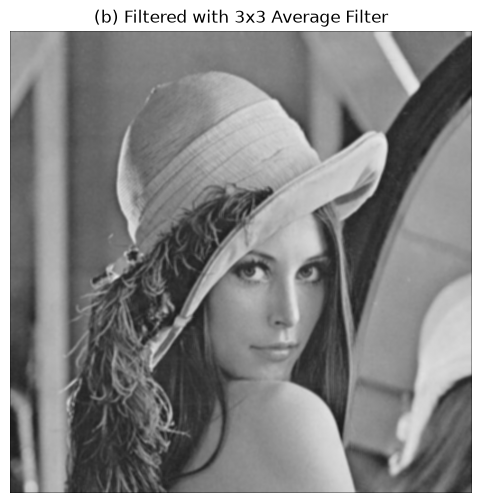

In [6]:
# 3x3 filter kernel
h_3x3 = np.ones((3, 3), dtype=np.float64) / 9.0

# 2D convolution with zero boundary conditions
y1 = convolve2d(x, h_3x3, mode='same', boundary='fill', fillvalue=0)

plt.figure(figsize=(6, 6))
plt.imshow(y1, cmap='gray', vmin=0, vmax=255)
plt.title('(b) Filtered with 3x3 Average Filter')
plt.axis('off')
plt.show()


## (c) 2D Filtering with $5 \times 5$ Averaging Filter
The $5 \times 5$ impulse response is:
$$
h_2[m, n] = \begin{cases} \frac{1}{25}, & -2 \le m, n \le 2 \\ 0, & \text{otherwise} \end{cases}
$$
Filtered using 2D convolution with zero boundary conditions.

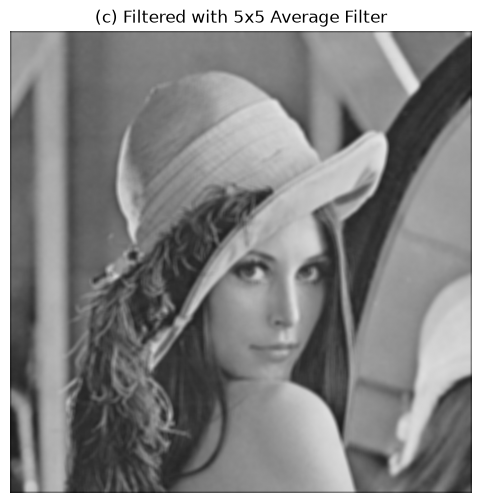

In [8]:
# 5x5 filter kernel
h_5x5 = np.ones((5, 5), dtype=np.float64) / 25.0

# 2D convolution with zero boundary conditions
y2 = convolve2d(x, h_5x5, mode='same', boundary='fill', fillvalue=0)

plt.figure(figsize=(6, 6))
plt.imshow(y2, cmap='gray', vmin=0, vmax=255)
plt.title('(c) Filtered with 5x5 Average Filter')
plt.axis('off')
plt.show()


## Side-by-side Visual Comparison

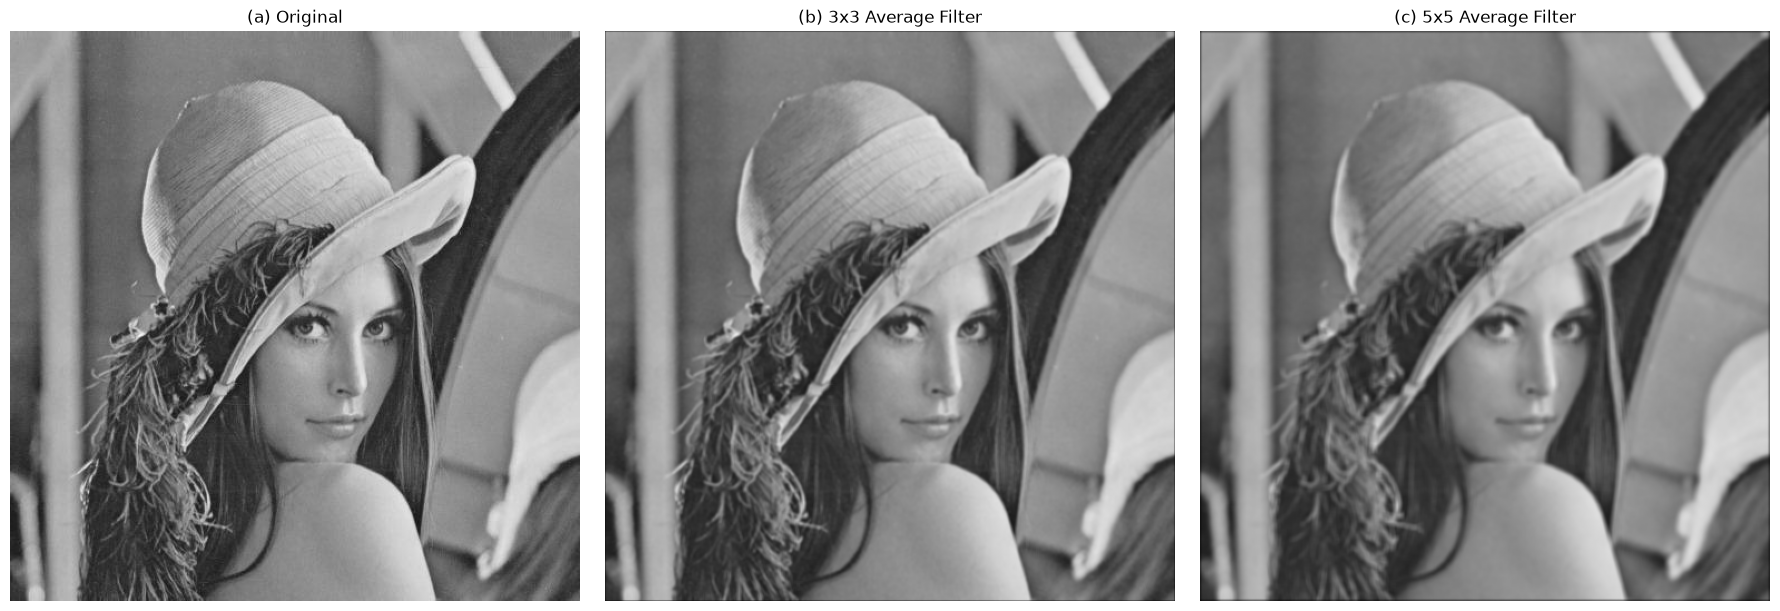

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(x, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('(a) Original')
axes[0].axis('off')

axes[1].imshow(y1, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('(b) 3x3 Average Filter')
axes[1].axis('off')

axes[2].imshow(y2, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('(c) 5x5 Average Filter')
axes[2].axis('off')

plt.tight_layout()
plt.show()
